In [ ]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.7 MB 18.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 17.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [panda


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Importing the pandas library
import pandas as pd

### CSV file

### Extract

In [ ]:
# Load the dataset
df= pd.read_csv(r"C:\Users\YAMINI RAVICHANDRAN\OneDrive\ドキュメント\starx\PYTHON\orders.csv")
df.head()

,order_id,product_id,quantity,order_date,customer_city,payment_mode,order_status
0,ORD2263,P009,1,10-02-2025,delhi,cash on delivery,Delivered
1,ORD1298,P003,10,Dec 25 2024,PUNE,CashonDelivery,Delivered
2,ORD1060,P002,8,02/05/2025,Pune,net banking,Cancelled
3,ORD2697,P002,9,2024-12-13,Ahmedabad,Cash on Delivery,Delivered
4,ORD1744,P008,2,Dec 07 2024,mumbai,Net Banking,Delivered


In [ ]:
# info() will give us the summary of the dataframe, 
# including the number of non-null values and the data types of each column.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_id       1954 non-null   str  
 1   product_id     2030 non-null   str  
 2   quantity       1980 non-null   str  
 3   order_date     2030 non-null   str  
 4   customer_city  2030 non-null   str  
 5   payment_mode   2030 non-null   str  
 6   order_status   2030 non-null   str  
dtypes: str(7)
memory usage: 111.1 KB


In [62]:
# describe() will give us the statistical summary of the numerical columns in the dataframe, including count,
#       mean, standard deviation, minimum, and maximum values.
df.describe(include='all')

,order_id,product_id,quantity,order_date,customer_city,payment_mode,order_status
count,2000,2000,2000.000000,2000,2000,2000,2000
unique,1925,43,NaN,NaN,8,6,3
top,ord1481,p036,NaN,NaN,kolkata,cash_on_delivery,delivered
freq,76,99,NaN,NaN,273,430,1173
mean,NaN,NaN,5.082000,2025-01-17 01:39:21.600000,NaN,NaN,NaN
min,NaN,NaN,0.000000,2024-01-12 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,2.000000,2024-12-22 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,5.000000,2025-01-15 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,8.000000,2025-02-11 00:00:00,NaN,NaN,NaN
max,NaN,NaN,10.000000,2025-12-02 00:00:00,NaN,NaN,NaN


In [ ]:
# Check for missing values in each column
df.isnull().sum()   

order_id         76
product_id        0
quantity         50
order_date        0
customer_city     0
payment_mode      0
order_status      0
dtype: int64

In [ ]:
# Fill missing values in 'order_id' and 'quantity' columns with the mode (most frequent value) of each column
df['order_id']= df['order_id'].fillna(df['order_id'].mode()[0])
df['quantity']= df['quantity'].fillna(0)
df.isnull().sum()

order_id         0
product_id       0
quantity         0
order_date       0
customer_city    0
payment_mode     0
order_status     0
dtype: int64

### Transformations and Standardization


In [ ]:
# Standardize the 'order_id' column by converting it to lowercase and stripping whitespace to ensure consistency in the data.
df['order_id']=df['order_id'].str.lower().str.strip()

# Standardize the 'product_id' column by converting it to lowercase, stripping whitespace, 
# and removing hyphens to ensure consistency in the data.
df['product_id']=df['product_id'].str.lower().str.strip()
df['product_id'] = df['product_id'].str.replace('-','',regex=False)

# Standardize the 'quantity' column by replacing various representations of missing or invalid values with '0' 
# and converting the column to integer type.
df['quantity']=pd.to_numeric(df['quantity'],errors='coerce').clip(lower=0).fillna(0).replace(9999,0)

# Convert 'order_date' column to datetime format
df['order_date'] = pd.to_datetime(df['order_date'],format='mixed')

# Standardize the 'customer_city' column by converting it to lowercase, replacing various representations 
# of city names with a consistent format, and stripping whitespace.
df['customer_city']=df['customer_city'].str.lower()
df['customer_city'] = df['customer_city'].str.replace({'bengaluru':'bangalore','madras':'chennai','bombay':'mumbai','calcutta':'kolkata'},
                                                      regex=True)
df['customer_city'] = df['customer_city'].str.strip()


# Standardize the 'payment_mode' column by converting it to lowercase, stripping whitespace,
#  and replacing various representations of payment modes with a consistent format.
df['payment_mode']=df['payment_mode'].str.lower().str.strip()
df['payment_mode'] = df['payment_mode'].replace(
    {'cash on delivery': 'cash_on_delivery',
     'cod': 'cash_on_delivery',
     'cashondelivery' : 'cash_on_delivery',
     'credit card' : 'credit_card',
     'cc': 'credit_card',
     'creditcard' : 'credit_card',
     'debitcard' : 'debit_card',
     'debit card' : 'debit_card',
     'dc': 'debit_card',
     'netbanking': 'net_banking',
     'net banking ': 'net_banking',
     'u.p.i': 'upi',
      })

# converting the 'order_status' column to lowercase to ensure consistency in the data.
df['order_status']=df['order_status'].str.lower()


In [9]:
df.isnull().sum()

order_id         0
product_id       0
quantity         0
order_date       0
customer_city    0
payment_mode     0
order_status     0
dtype: int64

In [ ]:
# Check for duplicate rows in the dataframe and remove them if any are found.
df=df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 0 to 2029
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       2000 non-null   str           
 1   product_id     2000 non-null   str           
 2   quantity       2000 non-null   int64         
 3   order_date     2000 non-null   datetime64[us]
 4   customer_city  2000 non-null   str           
 5   payment_mode   2000 non-null   str           
 6   order_status   2000 non-null   str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 125.0 KB


### Load the file and save it in csv format

In [13]:
# Save the cleaned dataframe to a new CSV file
df.to_csv('Cleaned_orders.csv', index=False)

print('Data cleaning completed and saved to Cleaned_orders.csv')

Data cleaning completed and saved to Cleaned_orders.csv


### Json File

### Extract

In [15]:
# Load the products dataset
import pandas as pd
df1=pd.read_json(r"C:\Users\YAMINI RAVICHANDRAN\OneDrive\ドキュメント\starx\PYTHON\products.json")
df1.head()


,product_id,product_name,category,unit_price
0,P001,Tata Salt 1kg,Staples,22
1,P002,Aashirvaad Atta 5kg,Staples,275
2,P003,Fortune Sunflower Oil 1L,Staples,135
3,P004,India Gate Basmati 1kg,Staples,110
4,P005,Toor Dal 500g,Staples,68


In [ ]:
# info() will give us the summary of the dataframe, 
# including the number of non-null values and the data types of each column.
df1.info()


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    40 non-null     str  
 1   product_name  40 non-null     str  
 2   category      40 non-null     str  
 3   unit_price    40 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.4 KB


In [61]:
# describe() will give us the statistical summary of the numerical columns in the dataframe, including count,
#       mean, standard deviation, minimum, and maximum values.
df1.describe(include='all')

,product_id,product_name,category,unit_price
count,40,40,40,40.000000
unique,40,40,8,NaN
top,p001,tata salt 1kg,staples,NaN
freq,1,1,5,NaN
mean,NaN,NaN,NaN,95.225000
std,NaN,NaN,NaN,76.403614
min,NaN,NaN,NaN,14.000000
25%,NaN,NaN,NaN,35.000000
50%,NaN,NaN,NaN,74.000000
75%,NaN,NaN,NaN,126.000000


In [18]:
# Check for missing values in each column
df1.isnull().sum()

product_id      0
product_name    0
category        0
unit_price      0
dtype: int64

In [19]:
df1['product_id']=df1['product_id'].str.lower().str.strip()
df1['product_name']=df1['product_name'].str.lower().str.strip()
df1['category']=df1['category'].str.lower().str.strip()

In [20]:
df1.head()

,product_id,product_name,category,unit_price
0,p001,tata salt 1kg,staples,22
1,p002,aashirvaad atta 5kg,staples,275
2,p003,fortune sunflower oil 1l,staples,135
3,p004,india gate basmati 1kg,staples,110
4,p005,toor dal 500g,staples,68


In [21]:
df1['category'].unique()

<StringArray>
[      'staples',         'dairy',        'snacks',     'beverages',
    'vegetables',     'household', 'personal care', 'ready to cook']
Length: 8, dtype: str

In [22]:
df1['unit_price'].unique()

array([ 22, 275, 135, 110,  68, 285,  48,  90,  20,  35,  30,  80,  65,
        40, 120, 125, 220, 185,  28,  25,  45, 195, 115,  95, 175,  55,
       299, 129,  89, 105,  14,  85])

In [23]:
df1=df1.drop_duplicates()

In [24]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    40 non-null     str  
 1   product_name  40 non-null     str  
 2   category      40 non-null     str  
 3   unit_price    40 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.4 KB


### Load

In [25]:
# Save the cleaned dataframe to a new CSV file
df1.to_csv('Cleaned_products.csv', index=False) 

### Combining the dataset

In [26]:
# merging the cleaned orders and products dataframes on the 'product_id' column using an 
# inner join to create a new dataframe called 'merged_df'.
merged_df = pd.merge(df, df1, on='product_id', how='inner')
merged_df.head()

,order_id,product_id,quantity,order_date,customer_city,payment_mode,order_status,product_name,category,unit_price
0,ord2263,p009,1,2025-10-02,delhi,cash_on_delivery,delivered,amul cheese slices 200g,dairy,135
1,ord1298,p003,10,2024-12-25,pune,cash_on_delivery,delivered,fortune sunflower oil 1l,staples,135
2,ord1060,p002,8,2025-02-05,pune,net banking,cancelled,aashirvaad atta 5kg,staples,275
3,ord2697,p002,9,2024-12-13,ahmedabad,cash_on_delivery,delivered,aashirvaad atta 5kg,staples,275
4,ord1744,p008,2,2024-12-07,mumbai,net banking,delivered,mother dairy curd 400g,dairy,48


In [31]:
merged_df=merged_df.drop_duplicates()

In [32]:
merged_df.to_csv("orders_report.csv", index=False)

print("Report saved successfully!")

Report saved successfully!


In [33]:
merged_df.isnull().sum()

order_id         0
product_id       0
quantity         0
order_date       0
customer_city    0
payment_mode     0
order_status     0
product_name     0
category         0
unit_price       0
dtype: int64

In [34]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1959 entries, 0 to 1958
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       1959 non-null   str           
 1   product_id     1959 non-null   str           
 2   quantity       1959 non-null   int64         
 3   order_date     1959 non-null   datetime64[us]
 4   customer_city  1959 non-null   str           
 5   payment_mode   1959 non-null   str           
 6   order_status   1959 non-null   str           
 7   product_name   1959 non-null   str           
 8   category       1959 non-null   str           
 9   unit_price     1959 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 153.2 KB


In [35]:
merged_df['quantity'].unique()

array([ 1, 10,  8,  9,  2,  3,  7,  4,  5,  6,  0])

In [48]:
!pip install matplotlib
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------- ---------------- 4.7/8.1 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 17.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------- ----------- 5.0/7.0 MB 23.4 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 19.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   --------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns


### QUERIES

### Q1	What is the total revenue generated across all orders this period?
Hint: Use .sum() on the total_revenue column.


In [44]:
merged_df['total_revenue']=merged_df['quantity'] * merged_df['unit_price']
merged_df['total_revenue']=merged_df['total_revenue'].where(merged_df['order_status'] == 'delivered')

sum=merged_df['total_revenue'].sum()
print("Total Revenue:", sum)     

Total Revenue: 497478.0


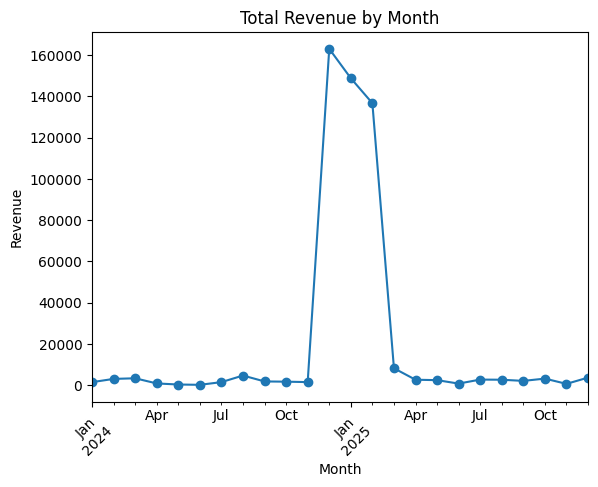

In [50]:
merged_df['month'] = merged_df['order_date'].dt.to_period('M')
monthly_revenue = merged_df.groupby('month')['total_revenue'].sum()
monthly_revenue.plot(kind='line', marker='o')
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()


### Q2	Which product category contributed the highest total revenue?
Hint: Use .groupby('category')['total_revenue'].sum() and find the top entry.


In [45]:
merged_df['total_revenue'] = merged_df['quantity'] * merged_df['unit_price']
merged_df['total_revenue']=merged_df['total_revenue'].where(merged_df['order_status'] == 'delivered')

total_revenue_by_category = merged_df.groupby('category')['total_revenue'].sum().idxmax()
total_revenue_by_category

'staples'

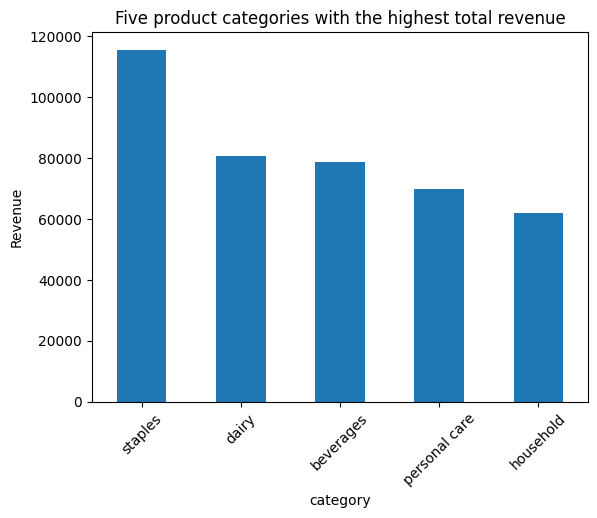

In [54]:
total_revenue_by_category = merged_df.groupby('category')['total_revenue'].sum()
five_categories = total_revenue_by_category.sort_values(ascending=False).head(5)
five_categories.plot(kind='bar')
plt.title("Five product categories with the highest total revenue")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()



### Q3	Which product was ordered the most by total quantity sold?
Hint: Use .groupby('product_name')['quantity'].sum().idxmax()


In [38]:
product_by_quantity_sold = merged_df.groupby('product_name')['quantity'].sum().idxmax()
product_by_quantity_sold

'maggi noodles 70g'

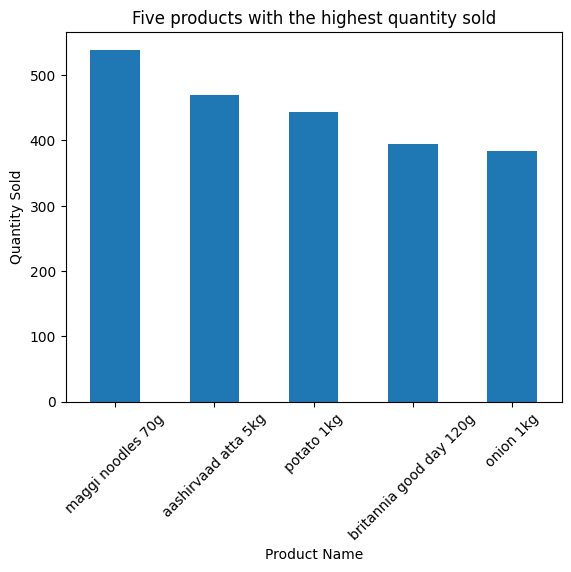

In [60]:
product_by_quantity_sold = merged_df.groupby('product_name')['quantity'].sum()
five_products = product_by_quantity_sold.sort_values(ascending=False).head(5)
five_products.plot(kind='bar')
plt.title("Five products with the highest quantity sold")
plt.xlabel("Product Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()


### Q4	Which city placed the highest number of orders?
Hint: Use .groupby('city')['order_id'].count().idxmax()


In [39]:
city_with_highest_orders= merged_df.groupby ('customer_city')['order_id'].count().idxmax()
city_with_highest_orders

'kolkata'

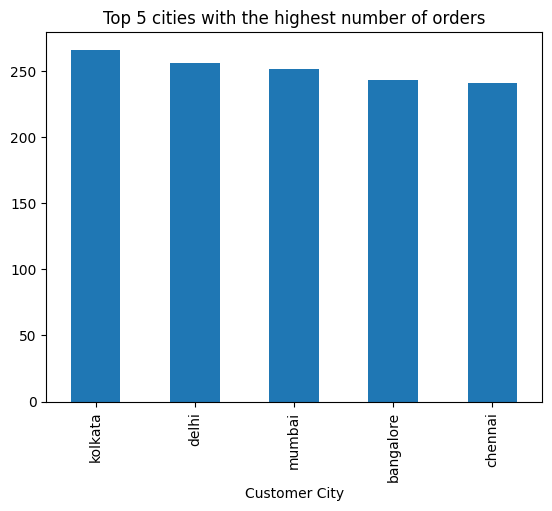

In [57]:
city_with_highest_orders= merged_df.groupby ('customer_city')['order_id'].count()
city_with_highest_orders = city_with_highest_orders.sort_values(ascending=False).head(5)
city_with_highest_orders.plot(kind='bar')
plt.title("Top 5 cities with the highest number of orders")
plt.xlabel("Customer City") 
plt.show()

### Q5	How many orders had a quantity of zero after null-filling, and what percentage of total orders is that?
Hint: Filter where quantity == 0, then calculate (count / total_rows) * 100



In [41]:
merged_df['quantity'] = pd.to_numeric(merged_df['quantity'], errors='coerce')

zero_orders = merged_df[merged_df['quantity'] == 0].shape[0]

total_rows = merged_df.shape[0]
percent = (zero_orders / total_rows) * 100

print("Orders with zero quantity:", zero_orders)
print("Percentage of orders with zero quantity:", percent)

Orders with zero quantity: 74
Percentage of orders with zero quantity: 3.777437468095967


Orders with zero quantity: 74
Other orders: 1885


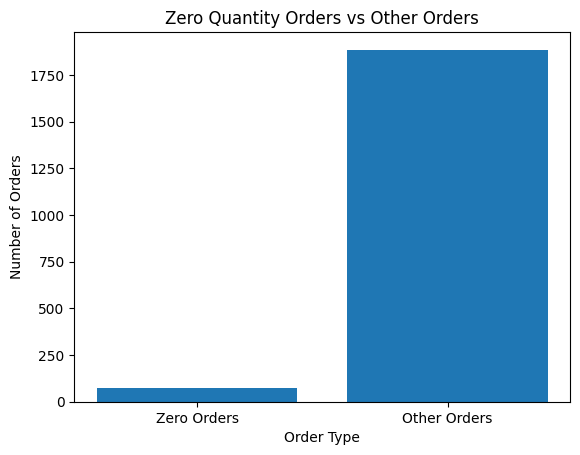

In [58]:
merged_df['quantity'] = pd.to_numeric(merged_df['quantity'], errors='coerce')

zero_orders = merged_df[merged_df['quantity'] == 0].shape[0]

total_rows = merged_df.shape[0]

other_orders = total_rows - zero_orders

print("Orders with zero quantity:", zero_orders)
print("Other orders:", other_orders)

labels = ['Zero Orders', 'Other Orders']
values = [zero_orders, other_orders]

plt.bar(labels, values)

plt.title("Zero Quantity Orders vs Other Orders")
plt.xlabel("Order Type")
plt.ylabel("Number of Orders")

plt.show()

### Q6	What is the average order value (average total_revenue per order)?
Hint: Use total_revenue.mean() on the merged DataFrame.




In [ ]:
merged_df['total_revenue'] = merged_df['quantity']* merged_df['unit_price']
avg_total_revenue=merged_df['total_revenue'].mean().round(2)
print(avg_total_revenue)

448.18
